# 17 – Vertiefung: Amplitudenspektrum und Leistungsspektrum (dBm)

Wir nutzen wieder das **verrauschte Sinussignal** aus dem Hauptnotebook (50 Hz, 2 V, $f_s = 1$ kHz, 1024 Punkte, AWGN $\sigma = 0{,}2$ V). Hier geht es um die **Darstellung** des Spektrums: **linear** und **logarithmisch** (Amplitudenspektrum), dann das **Leistungsspektrum** in **dBm** mit Marker und Beschriftung sowie den Zusammenhang zwischen Amplituden- und Leistungsspektrum.

**Navigation:** [← 17_Spektralanalyse (Hauptkapitel)](17_Spektralanalyse.ipynb) | Amplituden- & Leistungsspektrum

## Signal wie im Hauptnotebook

Sinus 50 Hz, Amplitude 2 V, Abtastrate 1 kHz, 1024 Punkte; plus AWGN mit $\sigma = 0{,}2$ V. FFT und einseitiges Amplitudenspektrum (Skalierung $2/N$).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
fs = 1000.0
N = 1024
f = 50.0
A = 2.0
sigma = 0.2

t = np.arange(N) / fs
signal = A * np.sin(2 * np.pi * f * t) + np.random.normal(0, sigma, N)

X = np.fft.fft(signal)
freq = np.fft.fftfreq(N, 1 / fs)
n_pos = N // 2 + 1
freq_einseitig = freq[:n_pos]
amplitude = np.abs(X[:n_pos]) * (2.0 / N)

print("Signal und einseitiges Amplitudenspektrum berechnet.")


Signal und einseitiges Amplitudenspektrum berechnet.


## Amplitudenspektrum: lineare und logarithmische y-Achse

Es handelt sich um ein **Amplitudenspektrum**: Auf der y-Achse steht die **Amplitude** (in V) der jeweiligen Frequenzkomponente – also der Betrag der komplexen FFT, skaliert mit $2/N$ für das einseitige Spektrum. Die **lineare** Darstellung zeigt die Amplituden direkt; die **logarithmische** Darstellung (y-Achse in dB, z.B. $20\,\log_{10}(|A|/A_\mathrm{ref})$) macht kleine Komponenten (z.B. Rauschen) sichtbar und entspricht oft der menschlichen Wahrnehmung (Lautstärke).

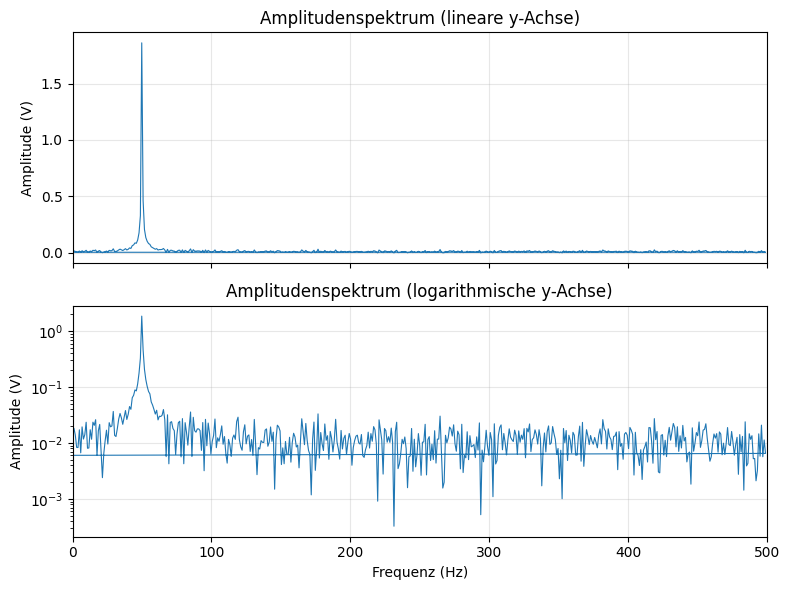

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

ax1.plot(freq_einseitig, amplitude, color="C0", linewidth=0.8)
ax1.set_ylabel("Amplitude (V)")
ax1.set_title("Amplitudenspektrum (lineare y-Achse)")
ax1.set_xlim(0, fs / 2)
ax1.grid(True, alpha=0.3)

ax2.semilogy(freq_einseitig, amplitude + 1e-10, color="C0", linewidth=0.8)
ax2.set_xlabel("Frequenz (Hz)")
ax2.set_ylabel("Amplitude (V)")
ax2.set_title("Amplitudenspektrum (logarithmische y-Achse)")
ax2.set_xlim(0, fs / 2)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Leistungsspektrum und Zusammenhang mit dem Amplitudenspektrum

Die **Leistung** einer Sinuskomponente mit Amplitude $A$ an einem Widerstand $R$ ist $P = A^2/(2R)$ (Effektivwert $A/\sqrt{2}$). Das **Leistungsspektrum** gibt die Leistung pro Frequenzbin an: Sie ist proportional zum **Quadrat des Amplitudenspektrums** ($P \propto A^2$). In **dBm** (Bezug 1 mW) gilt:
$$ P_{\mathrm{dBm}} = 10 \cdot \log_{10}\left(\frac{P}{1\,\mathrm{mW}}\right) = 10 \cdot \log_{10}\left(\frac{A^2/(2R)}{10^{-3}}\right)\,. $$
Mit $R = 50\,\Omega$: $P_{\mathrm{dBm}} = 10\,\log_{10}(A^2/(2 \cdot 50 \cdot 10^{-3})) = 10\,\log_{10}(A^2/0{,}1)$.

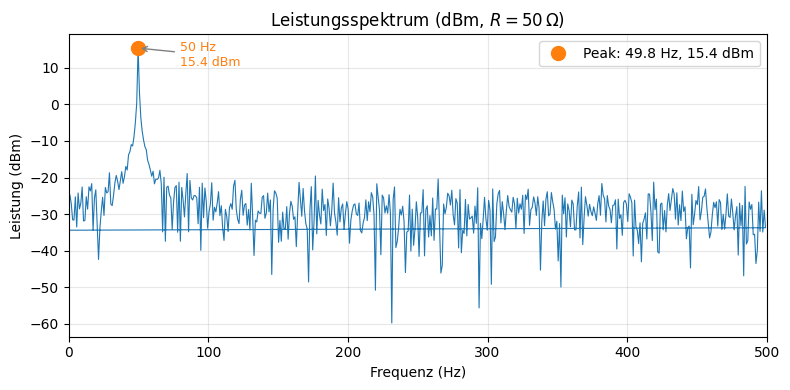

In [6]:
R = 50.0   # Bezugswiderstand in Ohm
# Leistung pro Bin: P = A^2/(2R), mit A = amplitude (einseitig)
P_W = (amplitude ** 2) / (2 * R)
# dBm: Bezug 1 mW = 1e-3 W
P_dBm = 10 * np.log10(P_W / 1e-3 + 1e-15)

plt.figure(figsize=(8, 4))
plt.plot(freq_einseitig, P_dBm, color="C0", linewidth=0.8)
plt.xlim(0, fs / 2)

# Marker am Maximum (ohne Gleichanteil)
idx_peak = 1 + np.argmax(P_dBm[1:])
f_peak = freq_einseitig[idx_peak]
P_peak_dBm = P_dBm[idx_peak]
plt.plot(f_peak, P_peak_dBm, "o", color="C1", markersize=10, label=f"Peak: {f_peak:.1f} Hz, {P_peak_dBm:.1f} dBm")
plt.annotate(f"{f_peak:.0f} Hz\n{P_peak_dBm:.1f} dBm", xy=(f_peak, P_peak_dBm), xytext=(f_peak + 30, P_peak_dBm - 5),
             fontsize=9, arrowprops=dict(arrowstyle="->", color="gray"), color="C1")

plt.xlabel("Frequenz (Hz)")
plt.ylabel("Leistung (dBm)")
plt.title(r"Leistungsspektrum (dBm, $R = 50\,\Omega$)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Kurz:** Amplitudenspektrum = Betrag der FFT (skaliert); lineare Achse für Amplituden in V, logarithmische Achse für bessere Sichtbarkeit kleiner Anteile. Leistungsspektrum $\propto A^2$; dBm-Skalierung mit Bezug 1 mW und $R = 50\,\Omega$. Marker und Beschriftung mit `plt.annotate` bzw. `plt.plot(..., 'o')` + `plt.legend`.

---

**Zurück:** [← 17_Spektralanalyse (Hauptkapitel)](17_Spektralanalyse.ipynb) | [Übersicht Python-Grundkurs](../README.md)